# Persistence — the closure hazard with duration dependence

How long does an arbitrage gap, once open, stay open? The closure branch of the
[existence equation](06_model_existence.ipynb) *already* answers this as a **discrete-time grouped
hazard**: restricting to `gap_lag > 0` and asking whether `D_t = 1` is, block by block, one
at-risk interval per row — "did the open spell survive this block?". The one thing the plain
closure hazard cannot see is **elapsed time**: every block of a spell is treated alike, whether it
is the spell's 1st or 8th.

This notebook adds that missing piece — `spell_duration`, the number of blocks the spell has
already survived (predetermined as of the block's own outcome) — turning the closure hazard into a
**duration-dependent** one (Wooldridge Ch. 20). One new covariate, the same estimator, 100 % of the
existing pipeline. All logic lives in `arblib.estimation`; this notebook only calls it.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

from arblib import estimation as est
from arblib.config import STUDY as S

panel = est.load_panel(S)
print("panel:", panel.shape)

quantile=0.4

panel: (1117870, 27)


## Build the closure risk set

`build_risk_set(..., condition="closure")` keeps the rows where a gap is open at `t-1`
(`gap_lag > 0`) with outcome `D_t` = "the spell survived this block". Each row already carries the
predetermined `spell_duration` (spell age as of `t-1`, stamped once on the panel by
`add_spell_columns`) and a `spell_id` identifying the ongoing spell — the one open at `t-1`, so
consecutive within-spell rows, including the closing block, share a cluster.

In [2]:
clo = est.build_risk_set(panel, quantile=quantile, condition="closure")


q40: dropping 1 pool pairs with no D variation (uninformative under pair FE): ['uniswap_3_vs_uniswap_5']
closure: dropping 3 pairs: ['uniswap_2_vs_uniswap_4', 'uniswap_4_vs_uniswap_6', 'uniswap_5_vs_pancake_2']
closure: (17978, 15) | D mean: 0.3816 | pairs: 22 | spell_duration max: 20


In [3]:
clo.groupby("pair").size()

pair
pancake_1_vs_pancake_2     896
uniswap_1_vs_pancake_1    3749
uniswap_1_vs_pancake_2    4022
uniswap_1_vs_uniswap_2    2191
uniswap_1_vs_uniswap_3    2115
uniswap_1_vs_uniswap_4     231
uniswap_1_vs_uniswap_5       6
uniswap_1_vs_uniswap_6     236
uniswap_2_vs_pancake_1     729
uniswap_2_vs_pancake_2    1410
uniswap_2_vs_uniswap_3     902
uniswap_2_vs_uniswap_5       4
uniswap_2_vs_uniswap_6      58
uniswap_3_vs_pancake_1     530
uniswap_3_vs_pancake_2     584
uniswap_3_vs_uniswap_4      75
uniswap_3_vs_uniswap_6      23
uniswap_4_vs_pancake_1      36
uniswap_4_vs_pancake_2     109
uniswap_5_vs_pancake_1       5
uniswap_6_vs_pancake_1      22
uniswap_6_vs_pancake_2      45
dtype: int64

In [4]:
clo = est.drop_pairs_by_event_floor(clo, S.min_events_per_pair, label="closure")
clo["spell_duration"].value_counts().sort_index()

closure: dropping 11 pairs with < 55 rarer-class events (min(n_D0, n_D1)): ['uniswap_1_vs_uniswap_4', 'uniswap_1_vs_uniswap_5', 'uniswap_2_vs_uniswap_5', 'uniswap_2_vs_uniswap_6', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_uniswap_6', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'uniswap_5_vs_pancake_1', 'uniswap_6_vs_pancake_1', 'uniswap_6_vs_pancake_2']
closure: kept 11 pairs, 17364 rows


spell_duration
1.0     10624
2.0      3516
3.0      1520
4.0       757
5.0       403
6.0       208
7.0       122
8.0        81
9.0        43
10.0       27
11.0       16
12.0       12
13.0       11
14.0        9
15.0        5
16.0        3
17.0        3
18.0        2
19.0        1
20.0        1
Name: count, dtype: int64

In [5]:
clo["D"].mean()

np.float64(0.388217000691085)

In [6]:
clo_c = est.center_continuous(clo, est.CLOSURE_DURATION_TERMS)

dur = est.fit_hazard_logit(clo_c, est.CLOSURE_DURATION_TERMS, cluster="pair")
print(dur.summary())

                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                17364
Model:                          Logit   Df Residuals:                    17322
Method:                           MLE   Df Model:                           41
Date:                Sat, 22 Aug 2026   Pseudo R-squ.:                 0.08132
Time:                        16:37:06   Log-Likelihood:                -10655.
converged:                       True   LL-Null:                       -11598.
Covariance Type:              cluster   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.2056      0.207     -0.993      0.321      -0.612       0.200
C(pair)[T.uniswap_1_vs_pancake_1]    -0.3665      0.043     -8

In [7]:
est.separation_report(dur, clo_c)

perfectly predicted (fitted p < 0.0001 or > 0.9999): 0 / 17364 obs (0.0%)

fixed-effect dummies by |z| (separation signature = big |coef|, tiny SE), top 8:
                                    coef  std_err   abs_z
C(pair)[T.uniswap_1_vs_uniswap_2] -1.161    0.079  14.705
C(pair)[T.uniswap_2_vs_pancake_1] -0.427    0.031  13.697
C(pair)[T.uniswap_1_vs_uniswap_6] -0.795    0.068  11.771
C(pair)[T.uniswap_3_vs_pancake_1] -0.266    0.023  11.550
C(pair)[T.uniswap_1_vs_pancake_1] -0.366    0.043   8.461
C(pair)[T.uniswap_1_vs_uniswap_3] -0.262    0.047   5.584
C(pair)[T.uniswap_3_vs_pancake_2] -0.079    0.017   4.552
C(pair)[T.uniswap_1_vs_pancake_2] -0.143    0.045   3.155


In [8]:
est.average_marginal_effects(dur, est.CLOSURE_DURATION_TERMS)

,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
log1p_gap_lag,0.022344,0.009544,2.341103,1.922686e-02,0.003638,0.041051
log_base_fee,0.086056,0.009240,9.313626,1.235413e-20,0.067947,0.104166
gas_util_lag,-0.030246,0.012370,-2.445035,1.448380e-02,-0.054492,-0.006001
tip_p90_lag,-0.002572,0.001554,-1.655847,9.775289e-02,-0.005617,0.000472
mev_lag,-0.004229,0.003785,-1.117353,2.638435e-01,-0.011648,0.003189
freq_lag,0.018468,0.007807,2.365653,1.799831e-02,0.003167,0.033769
log_vol,0.063799,0.011443,5.575586,2.466976e-08,0.041372,0.086226
spell_duration,0.011267,0.002798,4.026448,5.662584e-05,0.005782,0.016751


## Spell-level view — Kaplan–Meier survival (lifelines)

Everything above is a *block-level* at-risk table (one row per open block). The classic survival
view takes the **spell** as the unit, so the dataframe has to be reshaped. `build_spell_table`
collapses the panel's canonical spells (`spell_id` / `spell_duration` from `add_spell_columns`) into
one row per spell:

- `duration` — the spell length in blocks (its final `spell_duration`);
- `observed` — lifelines' `event_observed`: `1` if closure is seen (the run is followed by a
  `Gap == 0` block), `0` if the spell is **right-censored** (its last block is the pair's last block
  in the window, so its true length is unknown).

That `observed` flag is the one thing the block panel never made explicit — the reshape is exactly
what turns "rows that just stop" into a proper censoring indicator. It is descriptive (no fixed
effects, no pair screening), so it keeps every spell across all pairs.

In [9]:

spells = est.build_spell_table(panel, quantile=quantile)
spells.head()

spells: 11146 | closed: 11146 | censored: 0 | left-truncated: 0 | median duration: 1.0


,pair,onset_block,last_block,duration,observed,left_truncated
0,pancake_1_vs_pancake_2,24552124,24552124,1,1,False
1,pancake_1_vs_pancake_2,24553588,24553588,1,1,False
2,pancake_1_vs_pancake_2,24553591,24553591,1,1,False
3,pancake_1_vs_pancake_2,24553596,24553598,3,1,False
4,pancake_1_vs_pancake_2,24553609,24553610,2,1,False


Fit the Kaplan–Meier estimator on `(duration, observed)` and read off
`S(t) = P(spell still open after t blocks)`. In this one-hour window nothing is censored (no spell
outlives the extraction), so the curve is the raw empirical survival — but the identical call handles
right-censoring unchanged on a longer sample.

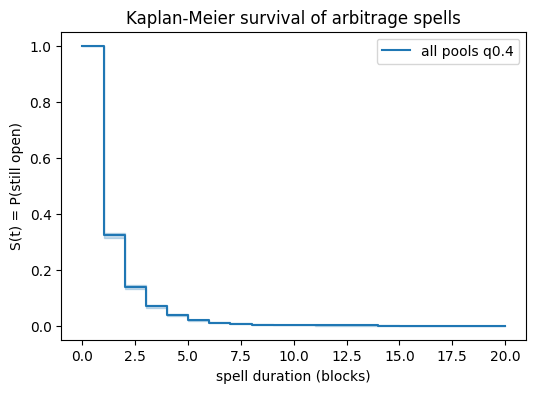

median survival (blocks): 1.0


,all pools q0.4,all pools q0.4_lower_0.95,all pools q0.4_upper_0.95
timeline,,,
0.0,1.0000,1.0000,1.0000
1.0,0.3234,0.3148,0.3321
2.0,0.1382,0.1318,0.1446
3.0,0.0687,0.0641,0.0735
4.0,0.0366,0.0332,0.0402
5.0,0.0187,0.0163,0.0213
6.0,0.0109,0.0091,0.0130
7.0,0.0073,0.0058,0.0090
8.0,0.0039,0.0028,0.0052


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(spells["duration"], event_observed=spells["observed"], label=f"all pools q{quantile}")

ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_xlabel("spell duration (blocks)"); ax.set_ylabel("S(t) = P(still open)")
ax.set_title("Kaplan-Meier survival of arbitrage spells")
plt.show()

print("median survival (blocks):", kmf.median_survival_time_)
kmf.survival_function_.join(kmf.confidence_interval_).round(4)